# Fetal health

## 1. Problem analysis and definition

* Defining the project goal




The goal of our fetal health assessment model is to develop an accurate and reliable classification system that will categorize fetuses into three classes (healthy, suspect, pathogenic).


* Identification of the problem

The problem being solved is a classification problem with 3 classes (healthy, suspect and pathogenic)

* Contribution of the project

There is a need for early detection of potential health problems in pregnant women in order to take preventive measures and provide support in the early stages of pregnancy.The model is intended to support clinicians in making informed decisions. This means that clinicians need tools to help them analyze fetal health data and make decisions that will improve pregnancy outcomes.The main purpose of the model is to reduce risks for the mother and newborn. This is achieved by timely recognition of potential complications and providing appropriate medical attention.

* Defining the measure of success

The measures of success that will be used in the project are the confusion matrix, sensitivity and accuracy

## 2. Data collection

* Selecting the database

The choosen database can be found on the [link](https://www.kaggle.com/datasets/andrewmvd/fetal-health-classification/data).

* Loading the database and format changes

In [1]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/My Drive/Masinsko ucenje/fetal_health.csv"

data = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
data.shape

(2126, 22)

In [3]:
data.columns

Index(['baseline value', 'accelerations', 'fetal_movement',
       'uterine_contractions', 'light_decelerations', 'severe_decelerations',
       'prolongued_decelerations', 'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'mean_value_of_long_term_variability', 'histogram_width',
       'histogram_min', 'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean',
       'histogram_median', 'histogram_variance', 'histogram_tendency',
       'fetal_health'],
      dtype='object')

In [4]:
data.describe()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,...,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,...,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,...,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


In [5]:
data.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


## 3. Data preparation

* Processing of missing values, detection and treatment of anomalies

Checking if there are values that are missing values

In [6]:
print(data.isnull().sum().sum())

0


* Identification of relevant attributes, and elimination of unnecessary ones that do not contribute to the quality of the model

When observing the statistical features of all attributes, there are several of them that have an unusual values. However, attribute selection is not only a technological issue, but also requires a deep understanding of the problem and domain. A combination of statistical methods and expert knowledge usually gives the best results in selecting important features.

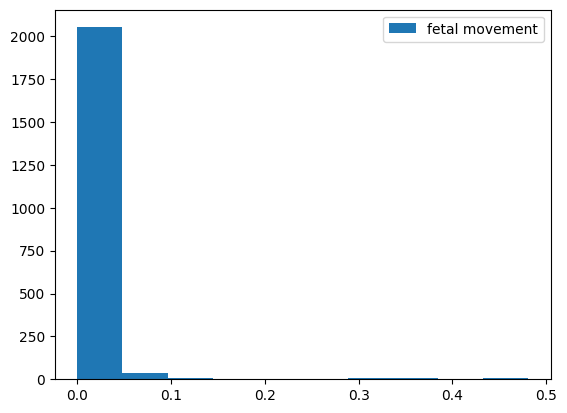

In [7]:
import matplotlib.pyplot as plt

plt.hist(data['fetal_movement'], bins=10, label='fetal movement')
plt.legend()
plt.show()

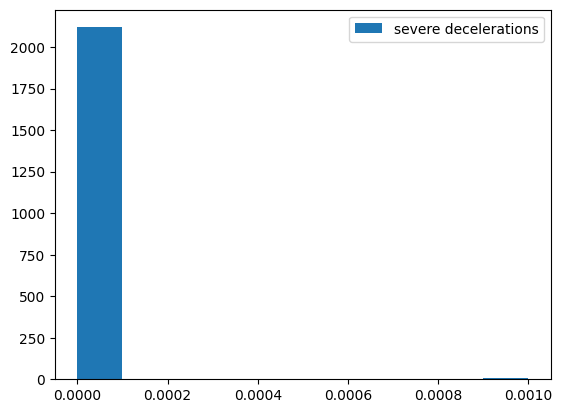

In [8]:
plt.hist(data['severe_decelerations'], bins=10, label='severe decelerations')
plt.legend()
plt.show()

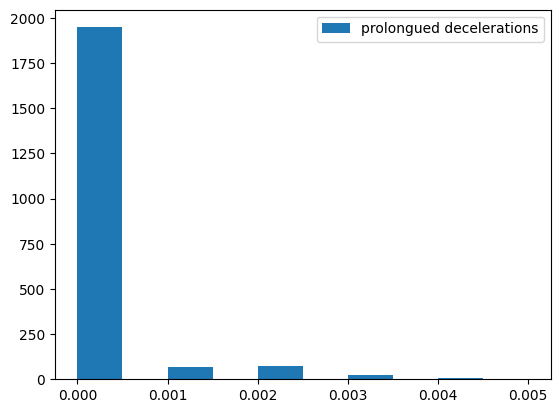

In [9]:
plt.hist(data['prolongued_decelerations'], bins=10, label='prolongued decelerations')
plt.legend()
plt.show()

Although many features have only a few samples that deviate from the values of approximately zero, considering the nature of the problem, we believe that it is necessary to keep such features as well, considering that such deviations from the mean value can show the seriousness of the fetal health problem

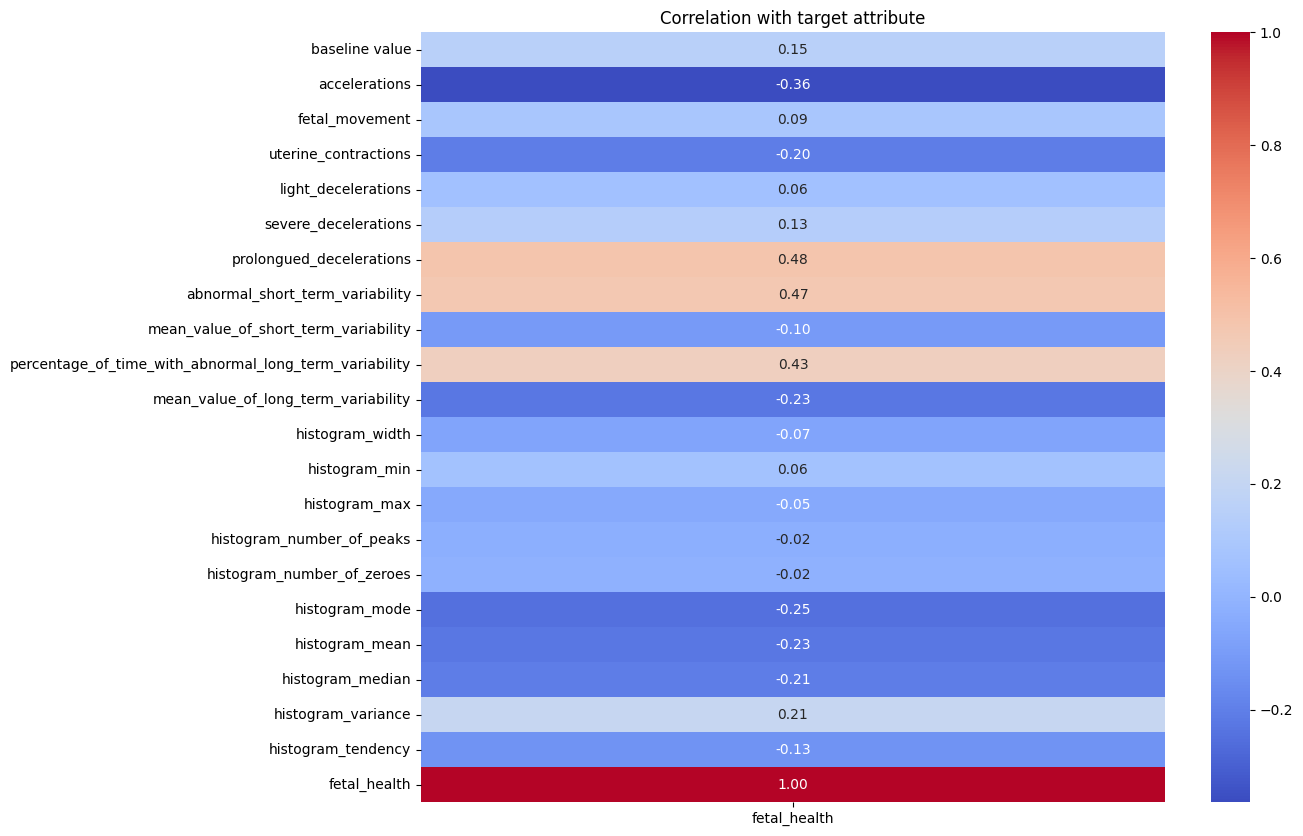

In [10]:
import seaborn as sns

corr_matrix = data.corr()
corr_with_target = corr_matrix['fetal_health']
plt.figure(figsize=(12, 10))
sns.heatmap(corr_with_target.to_frame(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation with target attribute')
plt.show()

When we observe the correlation between the features with the target attribute we can notice that the features *'histogram_min', 'histogram_max', 'histogram_number_of_peaks' and 'histogram_number_of_zeroes'* are not that relevant for us to observe, since their correlation with the target attribute is close to zero

In [11]:
data.drop(['histogram_width', 'histogram_min','histogram_max','histogram_number_of_peaks','histogram_number_of_zeroes'], axis=1, inplace=True)

## 4. Data Analysis

* Structure analysis, distribution and nature of numeric attributes

i.   Baseline value


This attrubute represents fetal heart rate

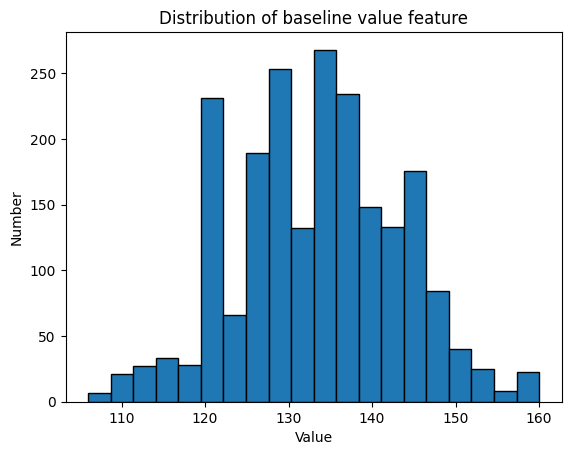

In [12]:
plt.hist(data['baseline value'], bins=20, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Number')
plt.title('Distribution of baseline value feature')
plt.show()

In [13]:
data['baseline value'].describe()

count    2126.000000
mean      133.303857
std         9.840844
min       106.000000
25%       126.000000
50%       133.000000
75%       140.000000
max       160.000000
Name: baseline value, dtype: float64

ii. Accelerations



This feature represents the pulse acceleration per second

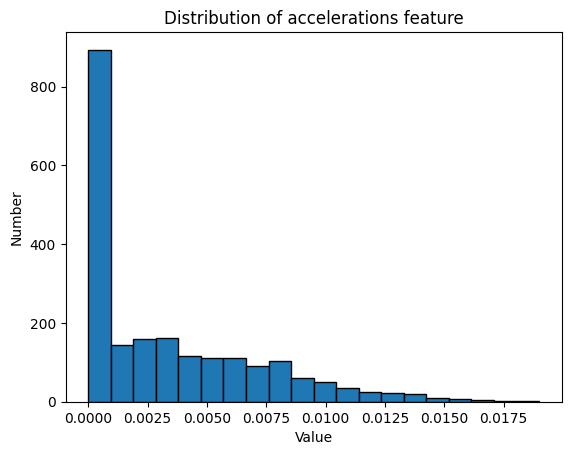

In [14]:
plt.hist(data['accelerations'], bins=20, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Number')
plt.title('Distribution of accelerations feature')
plt.show()

In [15]:
data['accelerations'].describe()

count    2126.000000
mean        0.003178
std         0.003866
min         0.000000
25%         0.000000
50%         0.002000
75%         0.006000
max         0.019000
Name: accelerations, dtype: float64

iii. Fetal movement

This feature represents the number of fetal movements per second

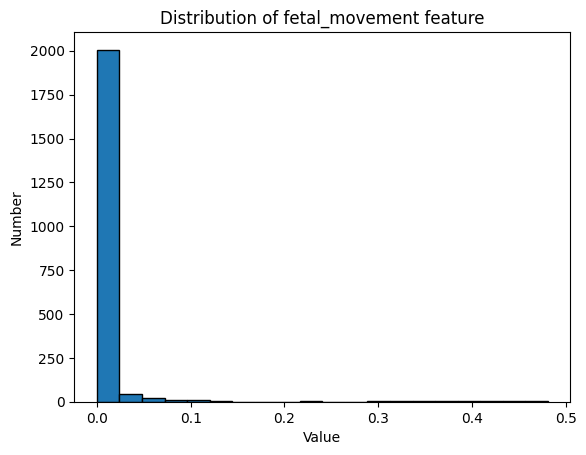

In [16]:
plt.hist(data['fetal_movement'], bins=20, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Number')
plt.title('Distribution of fetal_movement feature')
plt.show()

In [17]:
data['fetal_movement'].describe()

count    2126.000000
mean        0.009481
std         0.046666
min         0.000000
25%         0.000000
50%         0.000000
75%         0.003000
max         0.481000
Name: fetal_movement, dtype: float64

iv. Uterine contractions

This feature represents the number of uterine contractions per second

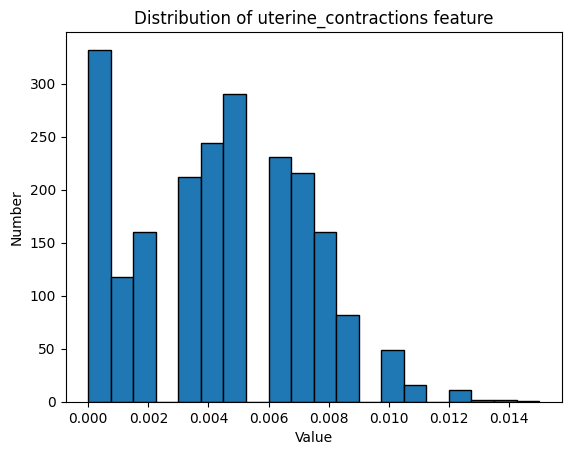

In [18]:
plt.hist(data['uterine_contractions'], bins=20, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Number')
plt.title('Distribution of uterine_contractions feature')
plt.show()

In [19]:
data['uterine_contractions'].describe()

count    2126.000000
mean        0.004366
std         0.002946
min         0.000000
25%         0.002000
50%         0.004000
75%         0.007000
max         0.015000
Name: uterine_contractions, dtype: float64

v. Light decelerations

This feature represents the number of light cardiac decelerations  of the heartbeat per second


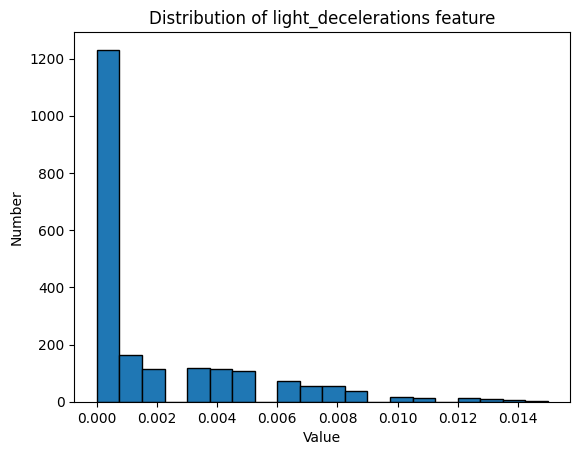

In [20]:
plt.hist(data['light_decelerations'], bins=20, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Number')
plt.title('Distribution of light_decelerations feature')
plt.show()

In [21]:
data['light_decelerations'].describe()

count    2126.000000
mean        0.001889
std         0.002960
min         0.000000
25%         0.000000
50%         0.000000
75%         0.003000
max         0.015000
Name: light_decelerations, dtype: float64

vi. Severe decelerations

This feature represents the number of severe cardiac decelerations per second

---




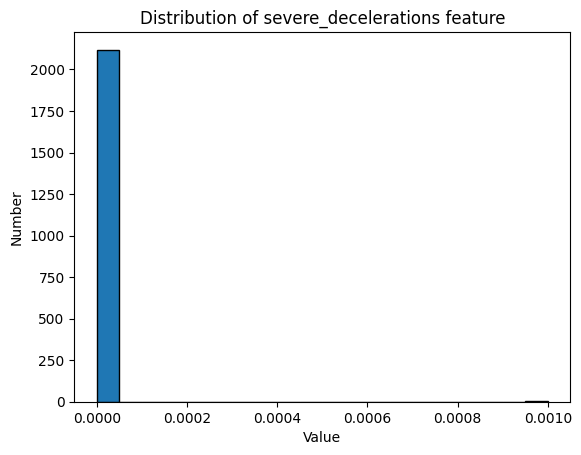

In [22]:
plt.hist(data['severe_decelerations'], bins=20, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Number')
plt.title('Distribution of severe_decelerations feature')
plt.show()

In [23]:
data['severe_decelerations'].describe()

count    2126.000000
mean        0.000003
std         0.000057
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.001000
Name: severe_decelerations, dtype: float64

vii. Prolongued decelerations

This feature represents the number of prolonged cardiac decelerations per second

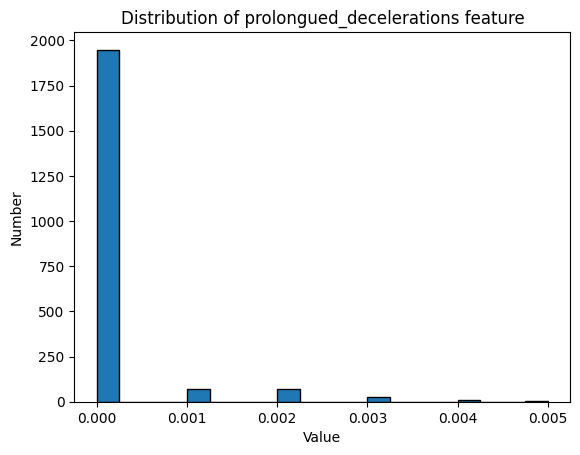

In [24]:
plt.hist(data['prolongued_decelerations'], bins=20, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Number')
plt.title('Distribution of prolongued_decelerations feature')
plt.show()

In [25]:
data['prolongued_decelerations'].describe()

count    2126.000000
mean        0.000159
std         0.000590
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.005000
Name: prolongued_decelerations, dtype: float64

viii. Abnormal short term variability

This feature represents the percentage of time with abnormal short-term heart rate variability

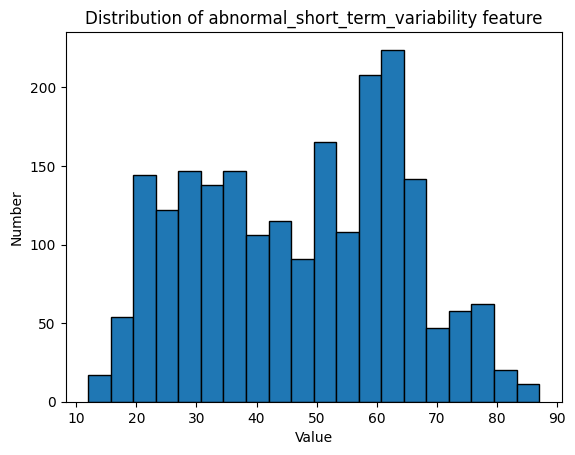

In [26]:
plt.hist(data['abnormal_short_term_variability'], bins=20, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Number')
plt.title('Distribution of abnormal_short_term_variability feature')
plt.show()

In [27]:
data['abnormal_short_term_variability'].describe()

count    2126.000000
mean       46.990122
std        17.192814
min        12.000000
25%        32.000000
50%        49.000000
75%        61.000000
max        87.000000
Name: abnormal_short_term_variability, dtype: float64

ix. Mean value of short term variability

This feature represents the mean short-term heart rate variability

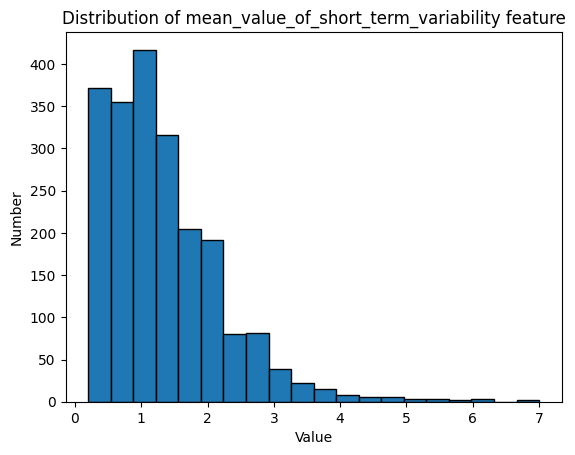

In [28]:
plt.hist(data['mean_value_of_short_term_variability'], bins=20, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Number')
plt.title('Distribution of mean_value_of_short_term_variability feature')
plt.show()

In [29]:
data['mean_value_of_short_term_variability'].describe()

count    2126.000000
mean        1.332785
std         0.883241
min         0.200000
25%         0.700000
50%         1.200000
75%         1.700000
max         7.000000
Name: mean_value_of_short_term_variability, dtype: float64

x. Percentage of time with abnormal long term variability

This feature represents the percentage of time with abnormal long-term heart rate variability

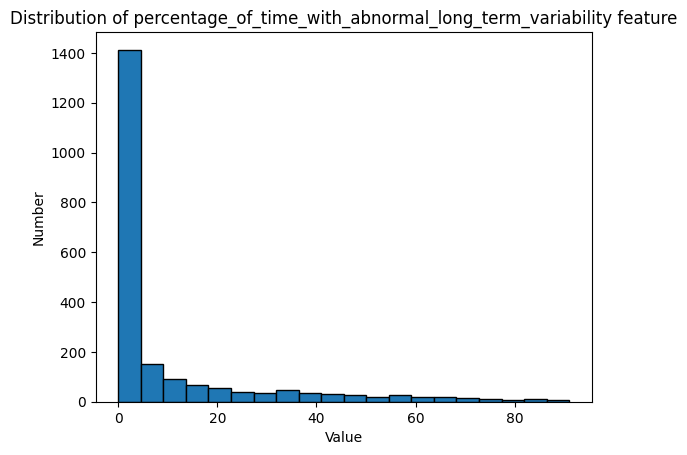

In [30]:
plt.hist(data['percentage_of_time_with_abnormal_long_term_variability'], bins=20, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Number')
plt.title('Distribution of percentage_of_time_with_abnormal_long_term_variability feature')
plt.show()

In [31]:
data['percentage_of_time_with_abnormal_long_term_variability'].describe()

count    2126.00000
mean        9.84666
std        18.39688
min         0.00000
25%         0.00000
50%         0.00000
75%        11.00000
max        91.00000
Name: percentage_of_time_with_abnormal_long_term_variability, dtype: float64

xi. Mean value of long term variability

This feature represents the mean long-term heart rate variability

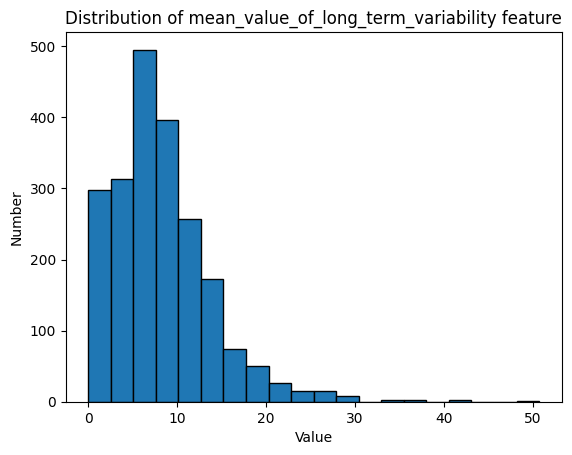

In [32]:
plt.hist(data['mean_value_of_long_term_variability'], bins=20, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Number')
plt.title('Distribution of mean_value_of_long_term_variability feature')
plt.show()

In [33]:
data['mean_value_of_long_term_variability'].describe()

count    2126.000000
mean        8.187629
std         5.628247
min         0.000000
25%         4.600000
50%         7.400000
75%        10.800000
max        50.700000
Name: mean_value_of_long_term_variability, dtype: float64

xii. Histogram mode

This feature represents histogram mode, made by using all
previous values from the record

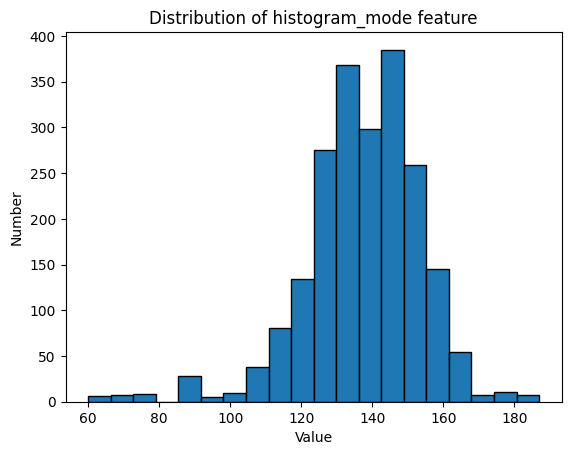

In [34]:
plt.hist(data['histogram_mode'], bins=20, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Number')
plt.title('Distribution of histogram_mode feature')
plt.show()

In [35]:
data['histogram_mode'].describe()

count    2126.000000
mean      137.452023
std        16.381289
min        60.000000
25%       129.000000
50%       139.000000
75%       148.000000
max       187.000000
Name: histogram_mode, dtype: float64

xii. Histogram mean

This feature represents histogram mean, made by using all
previous values from the record

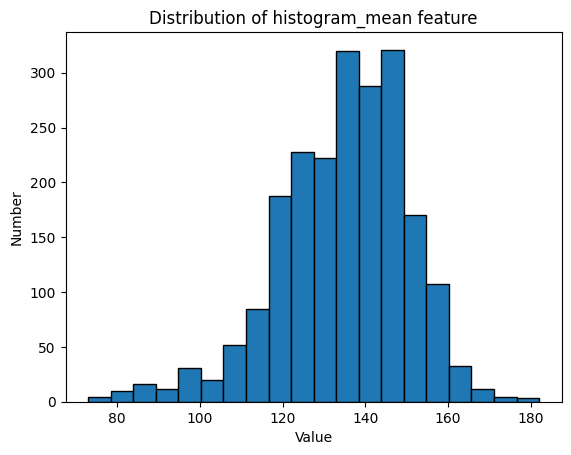

In [36]:
plt.hist(data['histogram_mean'], bins=20, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Number')
plt.title('Distribution of histogram_mean feature')
plt.show()

In [37]:
data['histogram_mean'].describe()

count    2126.000000
mean      134.610536
std        15.593596
min        73.000000
25%       125.000000
50%       136.000000
75%       145.000000
max       182.000000
Name: histogram_mean, dtype: float64

xiv. Histogram median

This feature represents histogram median, made by using all
previous values from the record

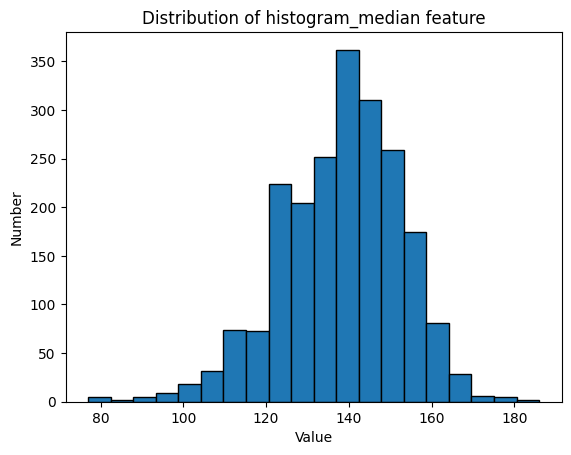

In [38]:
plt.hist(data['histogram_median'], bins=20, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Number')
plt.title('Distribution of histogram_median feature')
plt.show()

In [39]:
data['histogram_median'].describe()

count    2126.000000
mean      138.090310
std        14.466589
min        77.000000
25%       129.000000
50%       139.000000
75%       148.000000
max       186.000000
Name: histogram_median, dtype: float64

xv. Histogram variance

This feature represents histogram variance, made by using all
previous values from the record

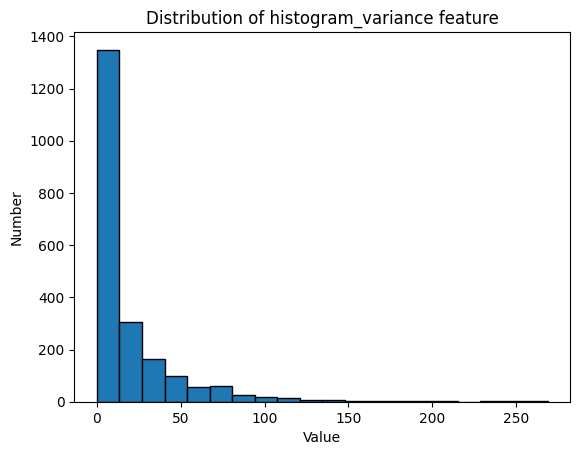

In [40]:
plt.hist(data['histogram_variance'], bins=20, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Number')
plt.title('Distribution of histogram_variance feature')
plt.show()

In [41]:
data['histogram_variance'].describe()

count    2126.000000
mean       18.808090
std        28.977636
min         0.000000
25%         2.000000
50%         7.000000
75%        24.000000
max       269.000000
Name: histogram_variance, dtype: float64

* Analysis of categorical characteristics and frequency of occurrence of certain categories

In [42]:
unique_counts = data.nunique()
print(unique_counts)

baseline value                                             48
accelerations                                              20
fetal_movement                                            102
uterine_contractions                                       16
light_decelerations                                        16
severe_decelerations                                        2
prolongued_decelerations                                    6
abnormal_short_term_variability                            75
mean_value_of_short_term_variability                       57
percentage_of_time_with_abnormal_long_term_variability     87
mean_value_of_long_term_variability                       249
histogram_mode                                             88
histogram_mean                                            103
histogram_median                                           95
histogram_variance                                        133
histogram_tendency                                          3
fetal_he

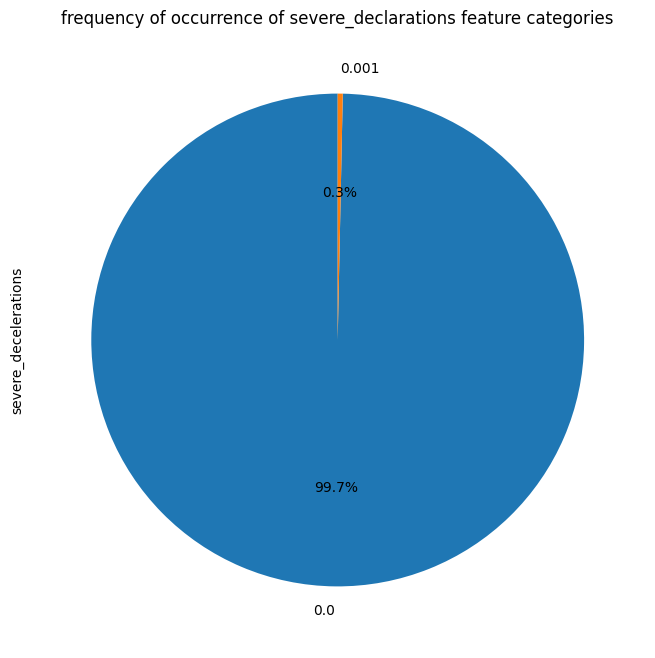

In [43]:
plt.figure(figsize=(8, 8))
data['severe_decelerations'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('frequency of occurrence of severe_declarations feature categories')
plt.show()

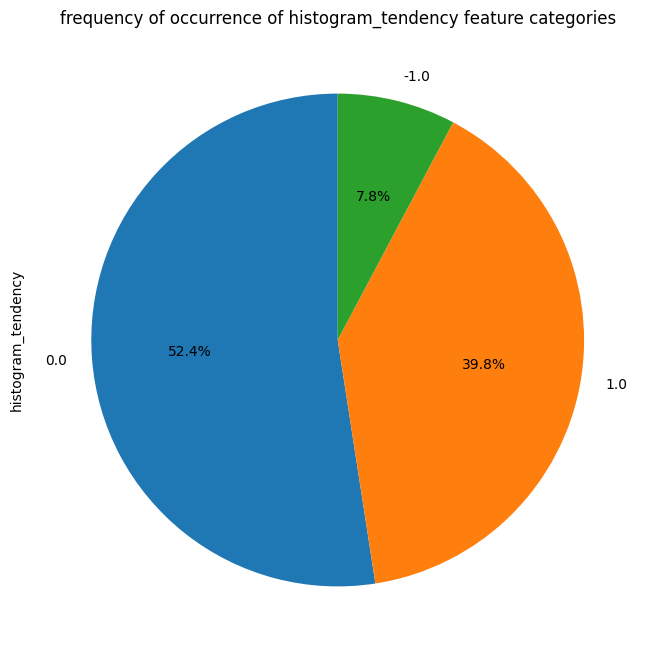

In [44]:
plt.figure(figsize=(8, 8))
data['histogram_tendency'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('frequency of occurrence of histogram_tendency feature categories')
plt.show()

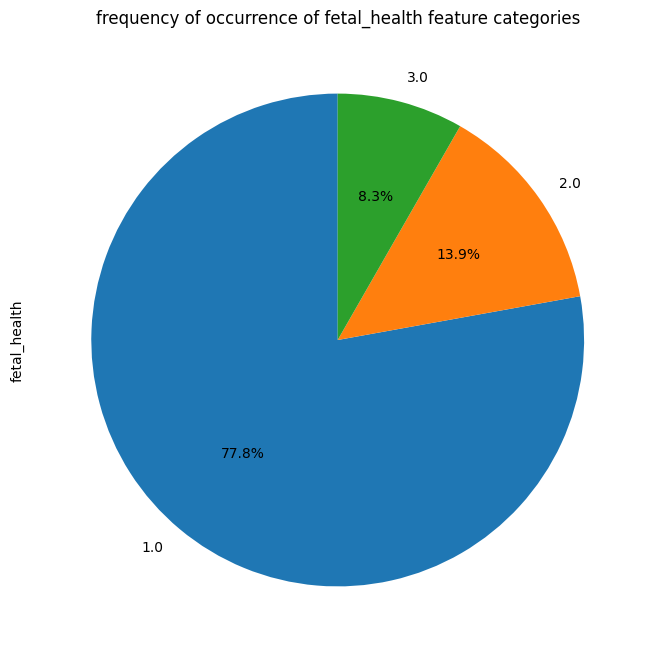

In [45]:
plt.figure(figsize=(8, 8))
data['fetal_health'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('frequency of occurrence of fetal_health feature categories')
plt.show()

* Correlation matrix

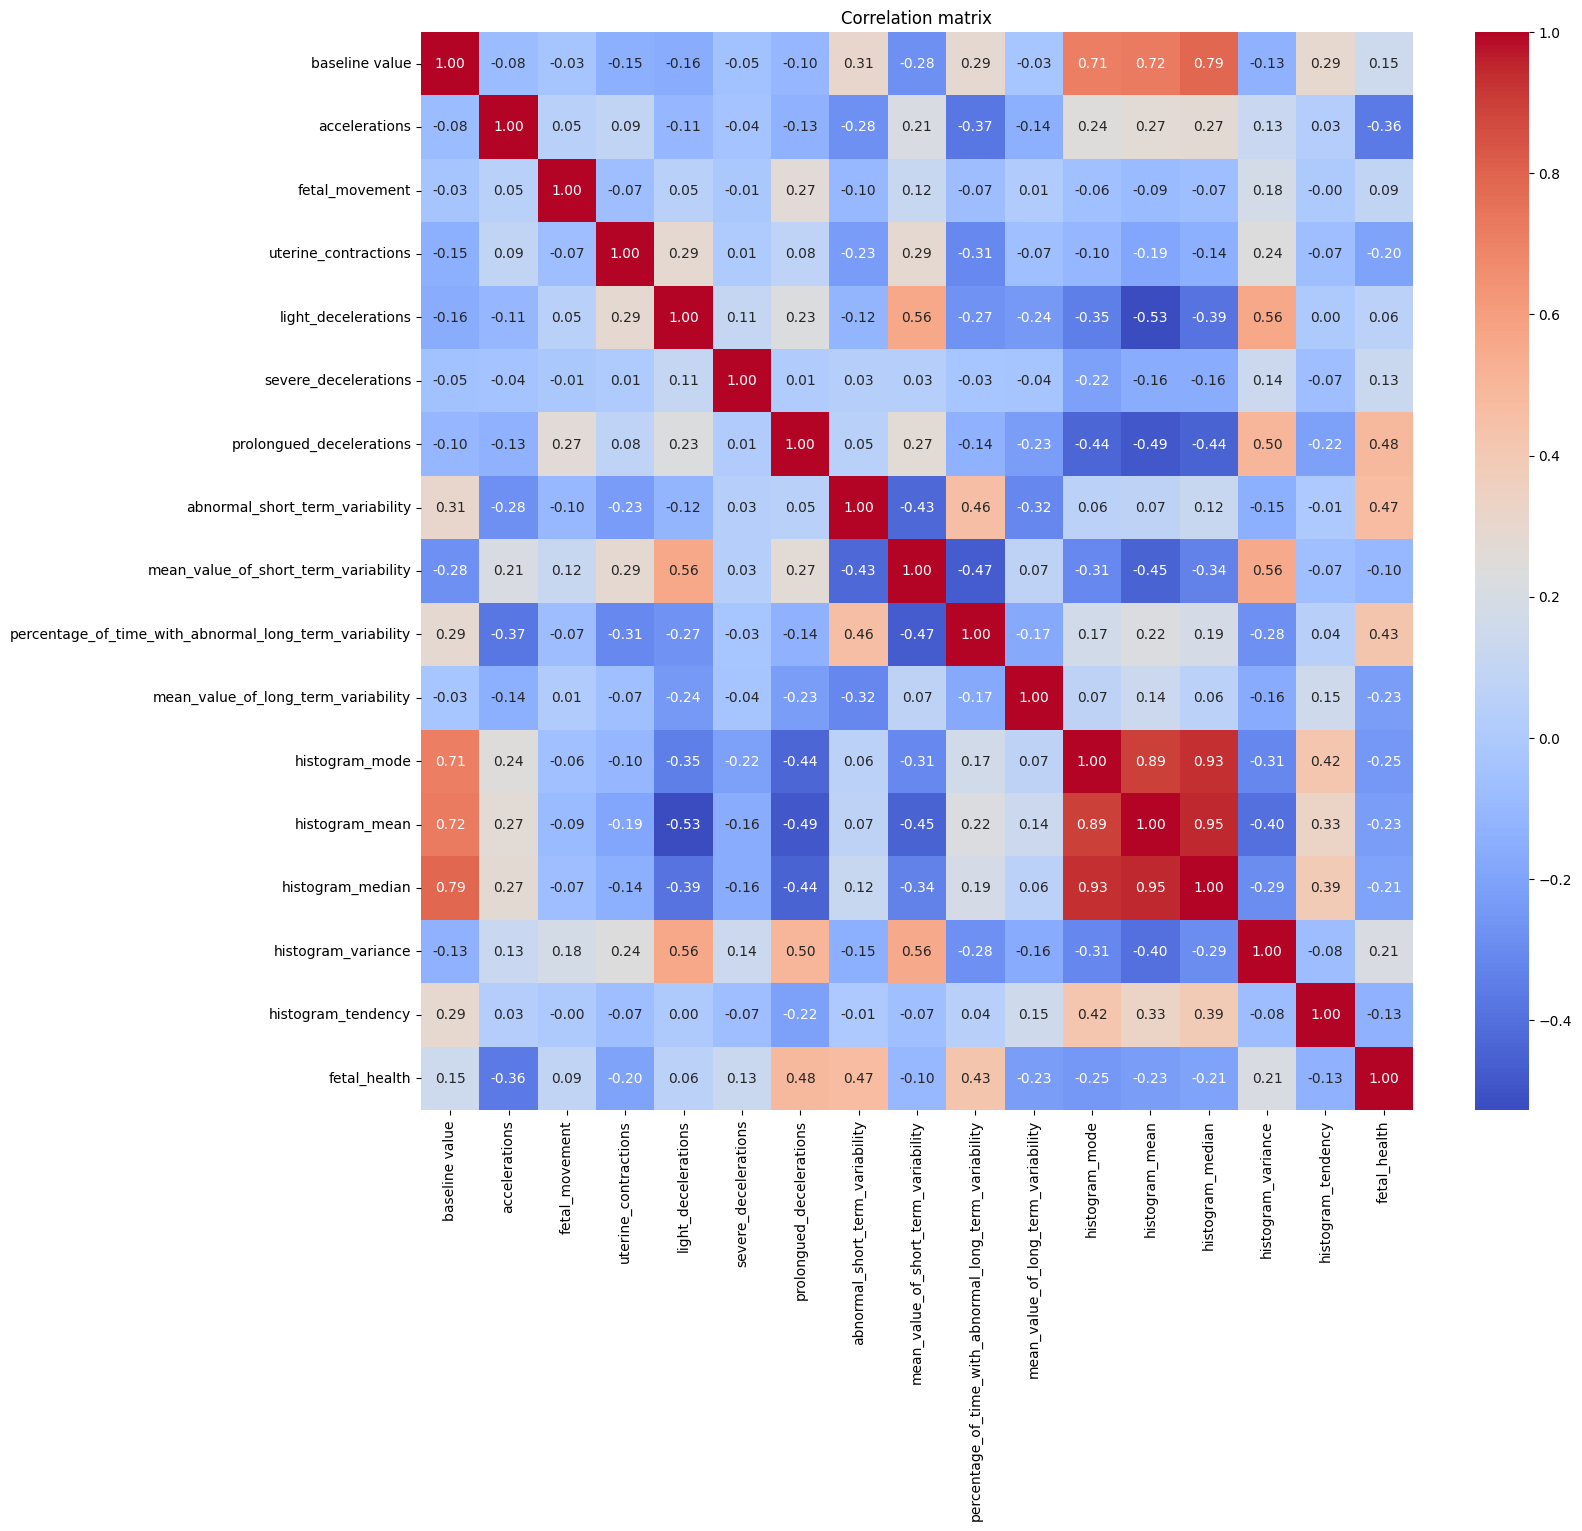

In [46]:
correlation_matrix = data.corr()

plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation matrix')
plt.show()

Since histogram_mode, histogram_median and histogram_mean have large correlation, we can aggregate these three features into one.

In [47]:
data['histogram_aggregation'] = data[['histogram_mode', 'histogram_mean', 'histogram_median']].mean(axis=1)
data = data.drop(['histogram_mode', 'histogram_mean', 'histogram_median'], axis=1)

The main issue with this data set could be the large imbalance of the three cathegories we are observing. Firstly, it could be resolved by over-sampeling the patogen fetuses and under-sampeling the heathy samples. The second method for balansing cathegories could be using the algorithms that consider this issue in their implementation. Finally, we could import K-Fold validation, that can minimize the differences in the cathegorically distribution.

In [48]:
 data['fetal_health'] = data['fetal_health'].replace({
        1.0: "NORMAL",
        2.0: "SUSPECT",
        3.0: "PATHOLOGICAL"
    })

## 5. Model Selection

* Metrics

The metrics that we will use for the quantitative assessment of the evaluation of our models are:

*   **Recall**
*   **F1 Score**
*   **Confusion Matrix**

* Models

Given that we are dealing with a problem that is part of the medical domain, it was important to us that when choosing models, we chose those that have characteristics that meet the challenges of medical data. For this purpose we carefully selected three algorithms :

1. **Random Forest**
2. **Support Vector Machine (SVM)**
3.   **XGBoost**

This selection stems from their proven effectiveness in similar medical research.

* Splitting the data into X and y set

In [49]:
y = data['fetal_health']
X = data.drop('fetal_health', axis=1)

* Splitting the data into training and test set

In [50]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# 1. Random forest

* K-Fold Crossvalidation

In [51]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, f1_score

kf = StratifiedKFold(n_splits=5, shuffle=True)
fin_recall = 0
fin_f1 = 0

for train_index, test_index in kf.split(x_train, y_train):
    classifier = RandomForestClassifier(n_estimators=100, random_state=42)
    classifier.fit(x_train.iloc[train_index, :], y_train.iloc[train_index])
    y_pred = classifier.predict(x_train.iloc[test_index, :])

    recall = recall_score(y_train.iloc[test_index], y_pred, average='weighted')

    f1 = f1_score(y_train.iloc[test_index], y_pred, average='weighted')

    fin_recall += recall
    fin_f1 += f1

fin_recall /= 5
fin_f1 /= 5

print(f'Average Recall: {fin_recall}')
print(f'Average F1 Score: {fin_f1}')

Average Recall: 0.946158052301341
Average F1 Score: 0.9444110273327748


## 1.1 Without standardization and dimensionality reduction

* Finding the best hyperparameters

In [52]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train, y_train)

print("Best parameters", grid_search.best_params_)


Best parameters {'max_depth': 10, 'n_estimators': 300}


* Initialization and model training

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1, random_state=42)

rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)

* Confusion matrix

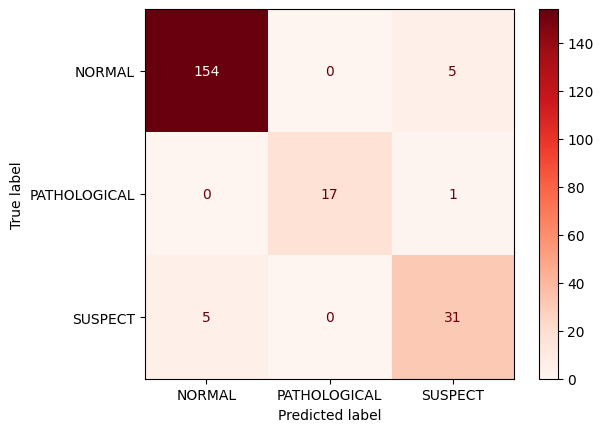

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

confusion_mat = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_mat,  display_labels=rf.classes_)
disp.plot(cmap="Reds")

* Metrics

In [55]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

classes = ['NORMAL', 'SUSPECT', 'PATHOLOGICAL']

for class_name in classes:
    test_class = [1 if x == class_name else 0 for x in y_test]
    pred_class = [1 if x == class_name else 0 for x in y_pred]

    accuracy = accuracy_score(test_class, pred_class)
    recall = recall_score(test_class, pred_class)
    f1 = f1_score(test_class, pred_class)

    print(f'Metrics for class {class_name}:')
    print(f'  Accuracy: {accuracy}')
    print(f'  Recall: {recall}')
    print(f'  F1 Score: {f1}')
    print()

micro_accuracy = accuracy_score(y_test, y_pred)
micro_recall = recall_score(y_test, y_pred, average='micro')
micro_f1 = f1_score(y_test, y_pred, average='micro')

print("Mikro Accuracy:", micro_accuracy)
print("Mikro Recall:", micro_recall)
print("Mikro F1 Score:", micro_f1)

Metrics for class NORMAL:
  Accuracy: 0.9530516431924883
  Recall: 0.9685534591194969
  F1 Score: 0.9685534591194969

Metrics for class SUSPECT:
  Accuracy: 0.9483568075117371
  Recall: 0.8611111111111112
  F1 Score: 0.8493150684931507

Metrics for class PATHOLOGICAL:
  Accuracy: 0.9953051643192489
  Recall: 0.9444444444444444
  F1 Score: 0.9714285714285714

Mikro Accuracy: 0.9483568075117371
Mikro Recall: 0.9483568075117371
Mikro F1 Score: 0.948356807511737


* Finding regions

Number of misclassified samples =  11


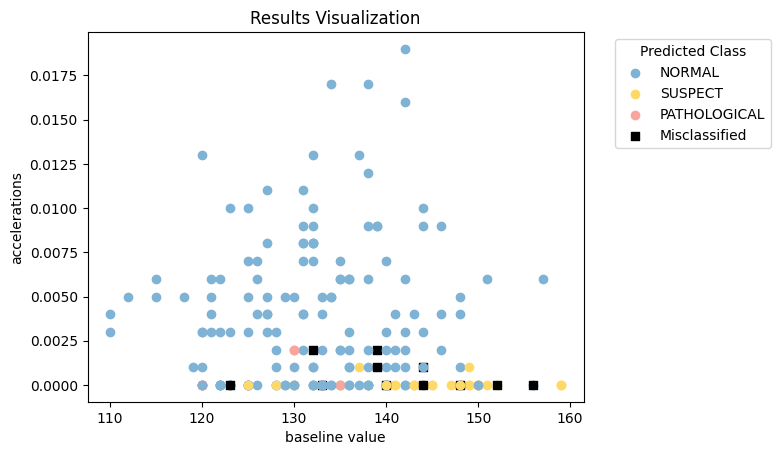

In [56]:
count_x = 0

class_colors = {
    'NORMAL': '#7FB3D5',
    'SUSPECT': '#FFD966',
    'PATHOLOGICAL': '#F7A59E'
}

for i in range(len(x_test)):
    actual_class = y_test.iloc[i]
    predicted_class = y_pred[i]

    if actual_class == predicted_class:
        color = class_colors[actual_class]
        plt.scatter(x_test.iloc[i, 0], x_test.iloc[i, 1], color=color, marker='o')
    else:
        count_x += 1
        plt.scatter(x_test.iloc[i, 0], x_test.iloc[i, 1], color='black', marker='s')

print("Number of misclassified samples = ", count_x)


for label, color in class_colors.items():
    plt.scatter([], [], color=color, label=label)

plt.scatter([], [], color='black', marker='s', label='Misclassified')
plt.legend(title='Predicted Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Results Visualization')
plt.xlabel(x_test.columns[0])
plt.ylabel(x_test.columns[1])
plt.show()

## 1.2 With standardization and dimensionality reduction

* Standardization

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_std = scaler.fit_transform(x_train)
x_test_std = scaler.transform(x_test)

*  Principal Component Analysis - PCA

In [58]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=9)

x_train_pca = pca.fit_transform(x_train_std)
x_test_pca = pca.transform(x_test_std)

* Initialization and model training

In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1, random_state=42)

rf.fit(x_train_pca, y_train)

y_pred = rf.predict(x_test_pca)

* Confusion matrix

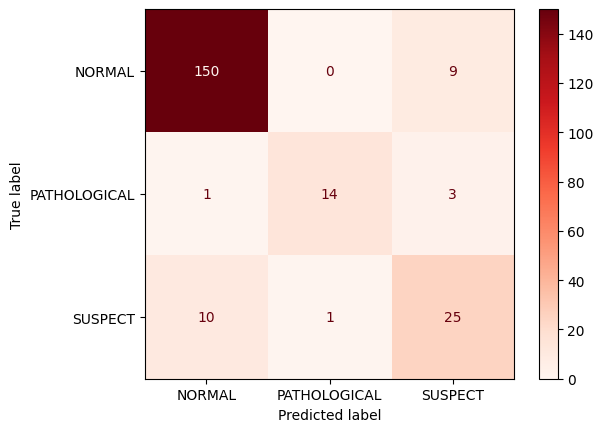

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

confusion_mat = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_mat,  display_labels=rf.classes_)
disp.plot(cmap="Reds")

* Metrics

In [61]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

classes = ['NORMAL', 'SUSPECT', 'PATHOLOGICAL']

for class_name in classes:
    test_class = [1 if x == class_name else 0 for x in y_test]
    pred_class = [1 if x == class_name else 0 for x in y_pred]

    accuracy = accuracy_score(test_class, pred_class)
    recall = recall_score(test_class, pred_class)
    f1 = f1_score(test_class, pred_class)

    print(f'Metrics for class {class_name}:')
    print(f'  Accuracy: {accuracy}')
    print(f'  Recall: {recall}')
    print(f'  F1 Score: {f1}')
    print()

micro_accuracy = accuracy_score(y_test, y_pred)
micro_recall = recall_score(y_test, y_pred, average='micro')
micro_f1 = f1_score(y_test, y_pred, average='micro')

print("Mikro Accuracy:", micro_accuracy)
print("Mikro Recall:", micro_recall)
print("Mikro F1 Score:", micro_f1)

Metrics for class NORMAL:
  Accuracy: 0.9061032863849765
  Recall: 0.9433962264150944
  F1 Score: 0.9375

Metrics for class SUSPECT:
  Accuracy: 0.892018779342723
  Recall: 0.6944444444444444
  F1 Score: 0.684931506849315

Metrics for class PATHOLOGICAL:
  Accuracy: 0.9765258215962441
  Recall: 0.7777777777777778
  F1 Score: 0.8484848484848485

Mikro Accuracy: 0.8873239436619719
Mikro Recall: 0.8873239436619719
Mikro F1 Score: 0.8873239436619719


* Finding regions

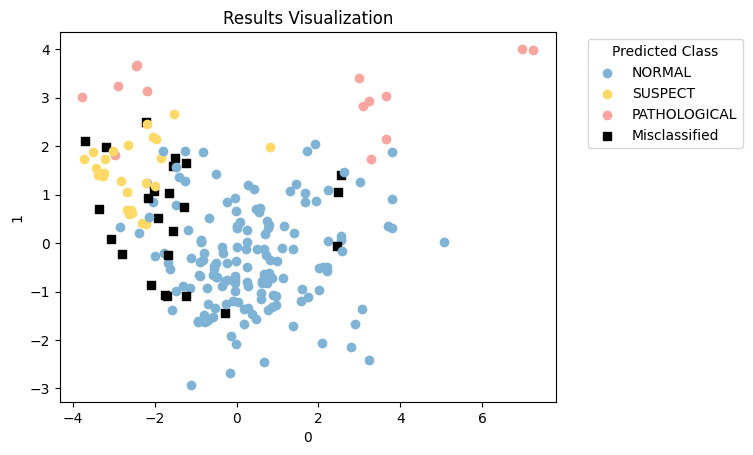

Number of misclassified samples =  24


In [62]:
import pandas as pd
import matplotlib.pyplot as plt

x_test_pca = pd.DataFrame(x_test_pca)
x_train_pca = pd.DataFrame(x_train_pca)

class_colors = {
    'NORMAL': '#7FB3D5',
    'SUSPECT': '#FFD966',
    'PATHOLOGICAL': '#F7A59E'
}

count_x = 0

for i in range(len(x_test_pca)):
    actual_class = y_test.iloc[i]
    predicted_class = y_pred[i]

    if actual_class == predicted_class:
        color = class_colors[actual_class]
        plt.scatter(x_test_pca.iloc[i, 0], x_test_pca.iloc[i, 1], color=color, marker='o')
    else:
        plt.scatter(x_test_pca.iloc[i, 0], x_test_pca.iloc[i, 1], color='black', marker='s')
        count_x += 1

for label, color in class_colors.items():
    plt.scatter([], [], color=color, label=label)

plt.scatter([], [], color='black', marker='s', label='Misclassified')
plt.legend(title='Predicted Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Results Visualization')
plt.xlabel(x_test_pca.columns[0])  # Postavljamo naziv prvog obeležja na x-osu
plt.ylabel(x_test_pca.columns[1])
plt.show()

print("Number of misclassified samples = ", count_x)

# 2. XGBoost

* Coding of the categorical values

In [63]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.fit_transform(y_test)

* K-Fold Crossvalidation

In [64]:
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, f1_score

kf = StratifiedKFold(n_splits=5, shuffle=True)
fin_recall = 0
fin_f1 = 0

for train_index, test_index in kf.split(x_train, y_train):
    classifier = XGBClassifier()
    classifier.fit(x_train.iloc[train_index, :], y_train_encoded[train_index])
    y_pred = classifier.predict(x_train.iloc[test_index, :])

    recall = recall_score(y_train_encoded[test_index], y_pred, average='weighted')
    f1 = f1_score(y_train_encoded[test_index], y_pred, average='weighted')

    fin_recall += recall
    fin_f1 += f1

fin_recall /= 5
fin_f1 /= 5

print("Sensitivity/Recall:", f"{recall*100:.2f}%")
print("F-score:", f"{f1*100:.2f}%")

Sensitivity/Recall: 95.55%
F-score: 95.50%


## 2.1 Without standardization and dimensionality reduction

* Finding the best hyperparameters

In [65]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300]
}

xgb_classifier = xgb.XGBClassifier()
grid_search = GridSearchCV(estimator=xgb_classifier, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(x_train, y_train_encoded)

print("The best parameters:", grid_search.best_params_)

The best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


* Initialization and model training

In [66]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay

xgb_classifier = XGBClassifier(max_depth= 3, learning_rate= 0.1, n_estimators= 200)
xgb_classifier.fit(x_train, y_train_encoded)
y_pred = xgb_classifier.predict(x_test)

* Confusion matrix

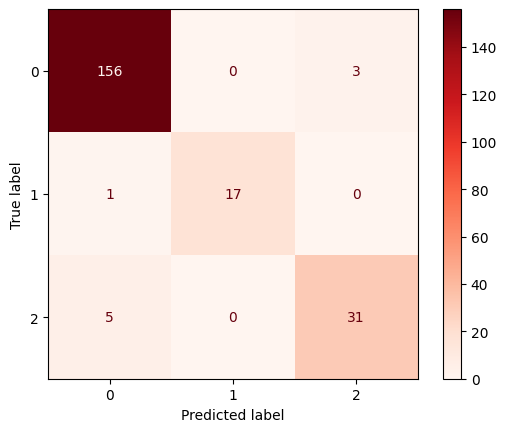

In [67]:
confusion_mat = confusion_matrix(y_test_encoded, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_mat,  display_labels=xgb_classifier.classes_)
disp.plot(cmap="Reds")

* Metrics

In [68]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

classes = [0, 1, 2]

for class_name in classes:
    test_class = [1 if x == class_name else 0 for x in y_test_encoded]
    pred_class = [1 if x == class_name else 0 for x in y_pred]

    accuracy = accuracy_score(test_class, pred_class)
    recall = recall_score(test_class, pred_class)
    f1 = f1_score(test_class, pred_class)

    print(f'Metrics for class {class_name}:')
    print(f'  Accuracy: {accuracy}')
    print(f'  Recall: {recall}')
    print(f'  F1 Score: {f1}')
    print()

micro_accuracy = accuracy_score(y_test_encoded, y_pred)
micro_recall = recall_score(y_test_encoded, y_pred, average='micro')
micro_f1 = f1_score(y_test_encoded, y_pred, average='micro')

print("Mikro Accuracy:", micro_accuracy)
print("Mikro Recall:", micro_recall)
print("Mikro F1 Score:", micro_f1)

Metrics for class 0:
  Accuracy: 0.9577464788732394
  Recall: 0.9811320754716981
  F1 Score: 0.9719626168224299

Metrics for class 1:
  Accuracy: 0.9953051643192489
  Recall: 0.9444444444444444
  F1 Score: 0.9714285714285714

Metrics for class 2:
  Accuracy: 0.9624413145539906
  Recall: 0.8611111111111112
  F1 Score: 0.8857142857142858

Mikro Accuracy: 0.9577464788732394
Mikro Recall: 0.9577464788732394
Mikro F1 Score: 0.9577464788732394


* Finding regions

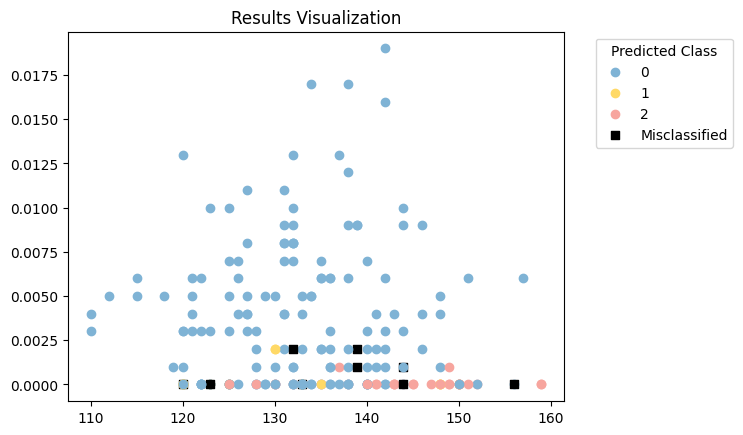

Number of misclassified samples =  9


In [69]:
class_colors = {
    0 : '#7FB3D5',
    1 : '#FFD966',
    2 : '#F7A59E'
}

count_x = 0

for i in range(len(x_test)):
    actual_class = y_test_encoded[i]
    predicted_class = y_pred[i]

    if actual_class == predicted_class:
        color = class_colors[actual_class]
        plt.scatter(x_test.iloc[i, 0], x_test.iloc[i, 1], color=color, marker='o')
    else:
        count_x += 1
        plt.scatter(x_test.iloc[i, 0], x_test.iloc[i, 1], color='black', marker='s')

for label, color in class_colors.items():
    plt.scatter([], [], color=color, label=label)

plt.scatter([], [], color='black', marker='s', label='Misclassified')
plt.legend(title='Predicted Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Results Visualization')
plt.show()

print("Number of misclassified samples = ", count_x)

## 2.2 With standardization and dimensionality reduction

* Initialization and model training

In [70]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay

xgb_classifier = XGBClassifier(max_depth= 3, learning_rate= 0.1, n_estimators= 200)
xgb_classifier.fit(x_train_pca, y_train_encoded)
y_pred = xgb_classifier.predict(x_test_pca)

* Confusion matrix

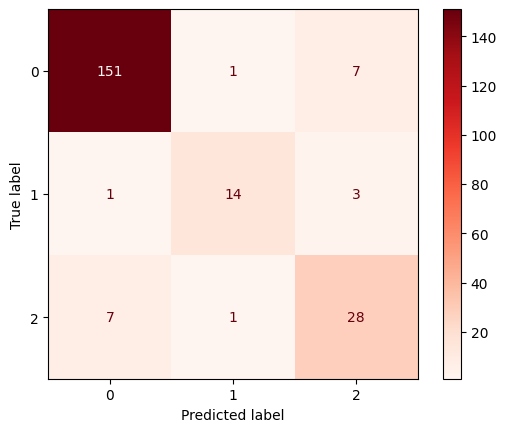

In [71]:
confusion_mat = confusion_matrix(y_test_encoded, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_mat,  display_labels=xgb_classifier.classes_)
disp.plot(cmap="Reds")

* Metrics

In [72]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

classes = [0, 1, 2]

for class_name in classes:
    test_class = [1 if x == class_name else 0 for x in y_test_encoded]
    pred_class = [1 if x == class_name else 0 for x in y_pred]

    accuracy = accuracy_score(test_class, pred_class)
    recall = recall_score(test_class, pred_class)
    f1 = f1_score(test_class, pred_class)

    print(f'Metrics for class {class_name}:')
    print(f'  Accuracy: {accuracy}')
    print(f'  Recall: {recall}')
    print(f'  F1 Score: {f1}')
    print()

micro_accuracy = accuracy_score(y_test_encoded, y_pred)
micro_recall = recall_score(y_test_encoded, y_pred, average='micro')
micro_f1 = f1_score(y_test_encoded, y_pred, average='micro')

print("Mikro Accuracy:", micro_accuracy)
print("Mikro Recall:", micro_recall)
print("Mikro F1 Score:", micro_f1)

Metrics for class 0:
  Accuracy: 0.9248826291079812
  Recall: 0.949685534591195
  F1 Score: 0.949685534591195

Metrics for class 1:
  Accuracy: 0.971830985915493
  Recall: 0.7777777777777778
  F1 Score: 0.823529411764706

Metrics for class 2:
  Accuracy: 0.9154929577464789
  Recall: 0.7777777777777778
  F1 Score: 0.7567567567567567

Mikro Accuracy: 0.9061032863849765
Mikro Recall: 0.9061032863849765
Mikro F1 Score: 0.9061032863849765


* Finding regions

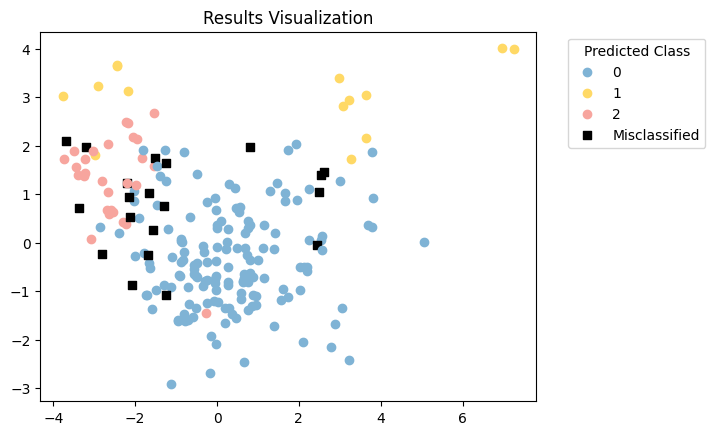

Number of misclassified samples =  20


In [73]:
import pandas as pd

x_test_pca = pd.DataFrame(x_test_pca)
x_train_pca = pd.DataFrame(x_train_pca)

class_colors = {
    0 : '#7FB3D5',
    1 : '#FFD966',
    2 : '#F7A59E'
}

count_x = 0

for i in range(len(x_test_pca)):
    actual_class = y_test_encoded[i]
    predicted_class = y_pred[i]

    if actual_class == predicted_class:
        color = class_colors[actual_class]
        plt.scatter(x_test_pca.iloc[i, 0], x_test_pca.iloc[i, 1], color=color, marker='o')
    else:
        count_x += 1
        plt.scatter(x_test_pca.iloc[i, 0], x_test_pca.iloc[i, 1], color='black', marker='s')

for label, color in class_colors.items():
    plt.scatter([], [], color=color, label=label)

plt.scatter([], [], color='black', marker='s', label='Misclassified')
plt.legend(title='Predicted Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Results Visualization')
plt.show()

print("Number of misclassified samples = ", count_x)


# 3. Support Vector Machines


## 3.1 Without standardization and dimensionality reduction

* K-Fold Crossvalidation


In [74]:
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import recall_score, f1_score

kf = StratifiedKFold(n_splits=5, shuffle=True)
fin_recall = 0
fin_f1 = 0

for train_index, test_index in kf.split(x_train, y_train):
    classifier = SVC(kernel='rbf', C=1)
    classifier.fit(x_train.iloc[train_index, :], y_train.iloc[train_index])
    y_pred = classifier.predict(x_train.iloc[test_index, :])

    recall = recall_score(y_train.iloc[test_index], y_pred, average='weighted')
    f1 = f1_score(y_train.iloc[test_index], y_pred, average='weighted')

    fin_recall += recall
    fin_f1 += f1

fin_recall /= 5
fin_f1 /= 5

print(f'Average Recall: {fin_recall}')
print(f'Average F1 Score: {fin_f1}')


Average Recall: 0.8567632222875343
Average F1 Score: 0.844233052903021


* Finding the best hyperparameters

In [75]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn import svm, datasets

param_grid = { 'kernel': ['linear', 'rbf', 'poly', 'sigmoid']}

svc = svm.SVC()
grid_search = GridSearchCV(estimator=svc,param_grid=param_grid, cv=5, scoring='accuracy',  n_jobs=-1)
grid_search.fit(x_train, y_train)

print("Best parameters:", grid_search.best_params_)
best_kernel = grid_search.best_params_['kernel']

Best parameters: {'kernel': 'linear'}


* Initialization and model training

In [76]:
from sklearn.model_selection import train_test_split

svm_classifier = SVC(kernel='linear', C=0.1, gamma=0.1)

svm_classifier.fit(x_train, y_train)

y_pred = svm_classifier.predict(x_test)

* Confusion matrix

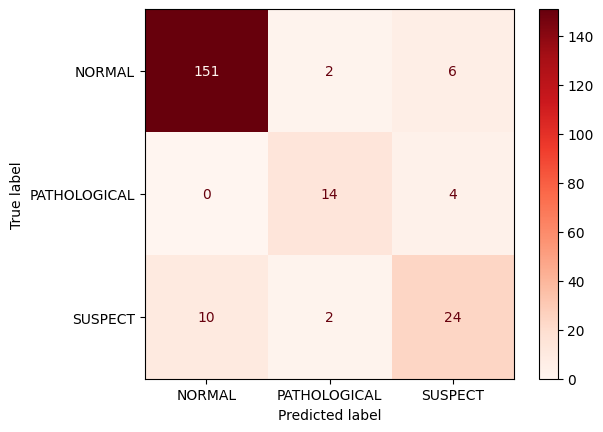

In [77]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

confusion_mat = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_mat,  display_labels=svm_classifier.classes_)
disp.plot(cmap="Reds")

* Metrics

In [78]:
from sklearn.metrics import accuracy_score, recall_score, f1_score
classes = ['NORMAL', 'SUSPECT', 'PATHOLOGICAL']

for class_name in classes:
    test_class = [1 if x == class_name else 0 for x in y_test]
    pred_class = [1 if x == class_name else 0 for x in y_pred]

    accuracy = accuracy_score(test_class, pred_class)
    recall = recall_score(test_class, pred_class)
    f1 = f1_score(test_class, pred_class)

    print(f'Metrics for class {class_name}:')
    print(f'  Accuracy: {accuracy}')
    print(f'  Recall: {recall}')
    print(f'  F1 Score: {f1}')
    print()

micro_accuracy = accuracy_score(y_test, y_pred)
micro_recall = recall_score(y_test, y_pred, average='micro')
micro_f1 = f1_score(y_test, y_pred, average='micro')

print("Mikro Accuracy:", micro_accuracy)
print("Mikro Recall:", micro_recall)
print("Mikro F1 Score:", micro_f1)

Metrics for class NORMAL:
  Accuracy: 0.9154929577464789
  Recall: 0.949685534591195
  F1 Score: 0.94375

Metrics for class SUSPECT:
  Accuracy: 0.8967136150234741
  Recall: 0.6666666666666666
  F1 Score: 0.6857142857142857

Metrics for class PATHOLOGICAL:
  Accuracy: 0.9624413145539906
  Recall: 0.7777777777777778
  F1 Score: 0.7777777777777778

Mikro Accuracy: 0.8873239436619719
Mikro Recall: 0.8873239436619719
Mikro F1 Score: 0.8873239436619719


* Finding regions

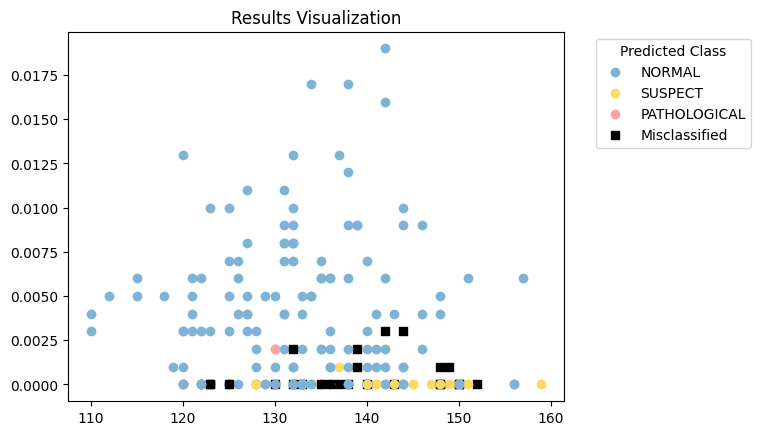

In [79]:
class_colors = {
    'NORMAL': '#7FB3D5',
    'SUSPECT': '#FFD966',
    'PATHOLOGICAL': '#F7A59E'
}

for i in range(len(x_test)):
    actual_class = y_test.iloc[i]
    predicted_class = y_pred[i]

    if actual_class == predicted_class:
        color = class_colors[actual_class]
        plt.scatter(x_test.iloc[i, 0], x_test.iloc[i, 1], color=color, marker='o')
    else:
        plt.scatter(x_test.iloc[i, 0], x_test.iloc[i, 1], color='black', marker='s')

for label, color in class_colors.items():
    plt.scatter([], [], color=color, label=label)

plt.scatter([], [], color='black', marker='s', label='Misclassified')
plt.legend(title='Predicted Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Results Visualization')
plt.show()

## 3.2 With standardization and dimensionality reduction

* Standardization

In [80]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_std = scaler.fit_transform(x_train)
x_test_std = scaler.transform(x_test)

*  Principal Component Analysis - PCA

In [81]:
from sklearn.decomposition import PCA
import numpy as np

num_components = 9
pca = PCA(n_components=num_components)

x_train_pca = pca.fit_transform(x_train_std)
x_test_pca = pca.transform(x_test_std)

* Initialization and model training

In [82]:
svm_classifier = SVC(kernel='linear', C=0.1, gamma=0.1)
svm_classifier.fit(x_train_pca, y_train)

y_pred = svm_classifier.predict(x_test_pca)


* Confusion matrix

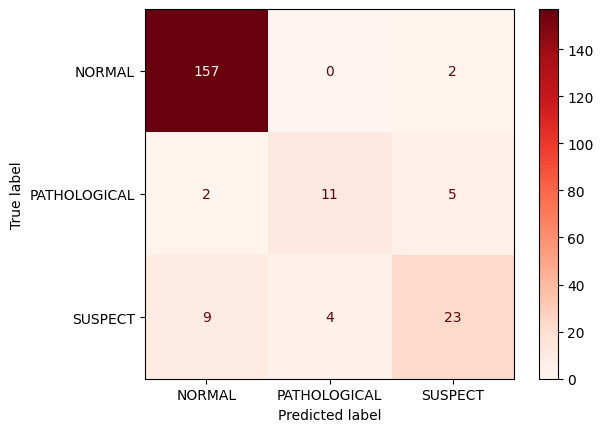

In [83]:
confusion_mat = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_mat,  display_labels=svm_classifier.classes_)
disp.plot(cmap="Reds")

* Metrics

In [84]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

classes = ['NORMAL', 'SUSPECT', 'PATHOLOGICAL']

for class_name in classes:
    test_class = [1 if x == class_name else 0 for x in y_test]
    pred_class = [1 if x == class_name else 0 for x in y_pred]

    accuracy = accuracy_score(test_class, pred_class)
    recall = recall_score(test_class, pred_class)
    f1 = f1_score(test_class, pred_class)

    print(f'Metrics for class {class_name}:')
    print(f'  Accuracy: {accuracy}')
    print(f'  Recall: {recall}')
    print(f'  F1 Score: {f1}')
    print()

micro_accuracy = accuracy_score(y_test, y_pred)
micro_recall = recall_score(y_test, y_pred, average='micro')
micro_f1 = f1_score(y_test, y_pred, average='micro')

print("Mikro Accuracy:", micro_accuracy)
print("Mikro Recall:", micro_recall)
print("Mikro F1 Score:", micro_f1)

Metrics for class NORMAL:
  Accuracy: 0.9389671361502347
  Recall: 0.9874213836477987
  F1 Score: 0.9602446483180428

Metrics for class SUSPECT:
  Accuracy: 0.9061032863849765
  Recall: 0.6388888888888888
  F1 Score: 0.696969696969697

Metrics for class PATHOLOGICAL:
  Accuracy: 0.9483568075117371
  Recall: 0.6111111111111112
  F1 Score: 0.6666666666666666

Mikro Accuracy: 0.8967136150234741
Mikro Recall: 0.8967136150234741
Mikro F1 Score: 0.8967136150234741


* Finding regions

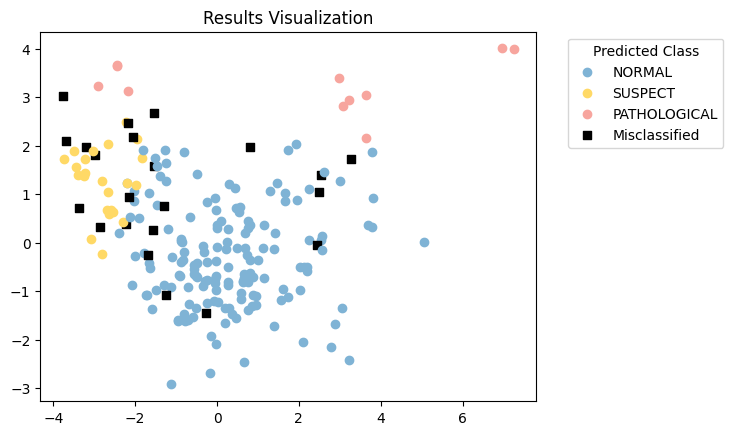

Number of misclassified samples =  22


In [85]:
import pandas as pd

x_test_pca = pd.DataFrame(x_test_pca)
x_train_pca = pd.DataFrame(x_train_pca)

count_x = 0

class_colors = {
    'NORMAL': '#7FB3D5',
    'SUSPECT': '#FFD966',
    'PATHOLOGICAL': '#F7A59E'
}

for i in range(len(x_test_pca)):
    actual_class = y_test.iloc[i]
    predicted_class = y_pred[i]

    if actual_class == predicted_class:
        color = class_colors[actual_class]
        plt.scatter(x_test_pca.iloc[i, 0], x_test_pca.iloc[i, 1], color=color, marker='o')
    else:
        count_x += 1
        plt.scatter(x_test_pca.iloc[i, 0], x_test_pca.iloc[i, 1], color='black', marker='s')

for label, color in class_colors.items():
    plt.scatter([], [], color=color, label=label)

plt.scatter([], [], color='black', marker='s', label='Misclassified')
plt.legend(title='Predicted Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Results Visualization')
plt.show()

print("Number of misclassified samples = ", count_x)

## 3.3 With standardization and resampling,without dimensionality reduction


*   Resampling of training and test data





In [86]:
from imblearn.combine import SMOTEENN

smote_enn = SMOTEENN()
x_train_resampled, y_train_resampled = smote_enn.fit_resample(x_train_std, y_train_encoded)

* Initialization and model training


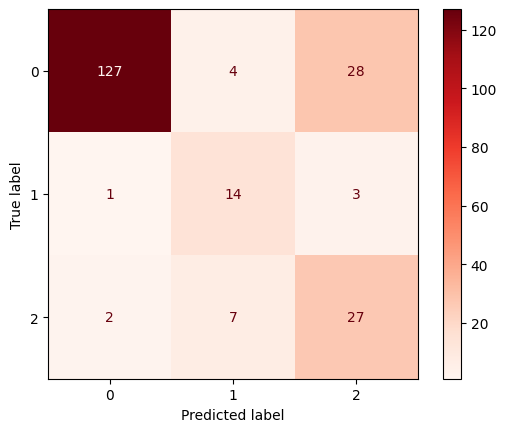

In [87]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

svm_classifier = SVC(kernel='linear', C=0.1, gamma=0.1)
svm_classifier.fit(x_train_resampled, y_train_resampled)
y_pred = svm_classifier.predict(x_test_std)

confusion_mat = confusion_matrix(y_test_encoded, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=confusion_mat,  display_labels=svm_classifier.classes_)
disp.plot(cmap="Reds")

* Metrics

In [88]:
from sklearn.metrics import accuracy_score, recall_score, f1_score
classes = [0, 1, 2]

for class_name in classes:
    test_class = [1 if x == class_name else 0 for x in y_test_encoded]
    pred_class = [1 if x == class_name else 0 for x in y_pred]

    accuracy = accuracy_score(test_class, pred_class)
    recall = recall_score(test_class, pred_class)
    f1 = f1_score(test_class, pred_class)

    print(f'Metrics for class {class_name}:')
    print(f'  Accuracy: {accuracy}')
    print(f'  Recall: {recall}')
    print(f'  F1 Score: {f1}')
    print()

micro_accuracy = accuracy_score(y_test_encoded, y_pred)
micro_recall = recall_score(y_test_encoded, y_pred, average='micro')
micro_f1 = f1_score(y_test_encoded, y_pred, average='micro')

print("Mikro Accuracy:", micro_accuracy)
print("Mikro Recall:", micro_recall)
print("Mikro F1 Score:", micro_f1)

Metrics for class 0:
  Accuracy: 0.8356807511737089
  Recall: 0.7987421383647799
  F1 Score: 0.8788927335640138

Metrics for class 1:
  Accuracy: 0.9295774647887324
  Recall: 0.7777777777777778
  F1 Score: 0.6511627906976745

Metrics for class 2:
  Accuracy: 0.812206572769953
  Recall: 0.75
  F1 Score: 0.574468085106383

Mikro Accuracy: 0.7887323943661971
Mikro Recall: 0.7887323943661971
Mikro F1 Score: 0.7887323943661971
